# Stopwords

In [2]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tejaswipinnaka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [4]:
sentence = 'He did not want her to go on her own'

sentence_nostop = ' '.join([x for x in sentence.lower().split() if x not in en_stopwords])

print(sentence_nostop)


want go


# Regex

In [5]:
path = 'C:\document\notes'
print(path)

C:\document
otes


In [6]:
path = r'C:\document\notes'
print(path)

C:\document\notes


In [3]:
import re

search = re.search('pattern', r'this does not contain apttern')
print(search)

None


In [4]:
search = re.search('pattern', r'this does not contain pattern')
print(search)

<re.Match object; span=(22, 29), match='pattern'>


In [5]:
string = 'sara is not coming'
print(string)

sara is not coming


In [6]:
newstring = re.sub('sara', 'sarah', string)
#sub(oldword, newword, string)
print(newstring)

sarah is not coming


In [7]:
customer_review = ['sam was a great help to me at the store', 'the cashier was very rude to me. I think her name is ed', 
                   'sarah helpd me with the items I needed quickly', 
                   'sara was good', 
                   'amazing work from sadeen, he helped me find whatever I wanted!']

sarah_review = []

for x in customer_review:
    if re.search('sarah?', x):
        sarah_review.append(x)

print(sarah_review)
        

['sarah helpd me with the items I needed quickly', 'sara was good']


In [81]:
reviewwitha = []

for x in customer_review:
    #starting with a
    if re.search('^a', x):
        reviewwitha.append(x)
print(reviewwitha)

['amazing work from sadeen, he helped me find whatever I wanted!']


In [47]:
reviewendigwitha = []

for x in customer_review:
    #ending with y
    if re.search('y$', x):
        reviewendigwitha.append(x)
print(reviewendigwitha)

['sarah helpd me with the items I needed quickly']


In [48]:
reviewendigwithneedwant = []

for x in customer_review:
    if re.search('need|want', x):
        reviewendigwithneedwant.append(x)
print(reviewendigwithneedwant)

['sarah helpd me with the items I needed quickly', 'amazing work from sadeen, he helped me find whatever I wanted!']


In [9]:
withoutpunc = []
for x in customer_review:
#checks for any words or whitespaces
    newword = re.sub('[^\w\s]', '', x)
    withoutpunc.append(newword)
print(withoutpunc)

['sam was a great help to me at the store', 'the cashier was very rude to me I think her name is ed', 'sarah helpd me with the items I needed quickly', 'sara was good', 'amazing work from sadeen he helped me find whatever I wanted']


# Tokenization

In [69]:
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize

sentence = 'Her name is x. His name is y'

sent_tokenize(sentence)




[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tejaswipinnaka/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['Her name is x.', 'His name is y']

In [68]:
word_tokenize(sentence)

['Her', 'name', 'is', 'x', '.', 'His', 'name', 'is', 'y']

# Stemming

In [70]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

connect_tokens = ['connecting', 'connected', 'connectivity', 'connects', 'connect']

for t in connect_tokens:
    print(t, ':', ps.stem(t))

connecting : connect
connected : connect
connectivity : connect
connects : connect
connect : connect


# Lemmatization

In [79]:
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejaswipinnaka/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [80]:
lm = WordNetLemmatizer()

for t in connect_tokens:
    print(t, ':', lm.lemmatize(t))

connecting : connecting
connected : connected
connectivity : connectivity
connects : connects
connect : connect


# N-grams


In [19]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
tokens = [
    "the", "quick", "brown", "fox", "jumps", "over", "the", "lazy", "dog",
    "and", "the", "fox", "was", "very", "quick", "the", "dog", "did", "not",
    "like", "the", "fox", "so", "the", "dog", "chased", "the", "fox", "around",
    "the", "forest", "the", "fox", "was", "clever", "and", "escaped", "the",
    "dog", "then", "the", "dog", "returned", "home", "the", "fox", "went",
    "back", "to", "the", "forest", "to", "hide", "and", "rest", "the", "dog",
    "was", "tired", "but", "the", "dog", "still", "wanted", "to", "play",
    "the", "fox", "watched", "from", "a", "tree", "the", "children", "played",
    "in", "the", "garden", "and", "the", "dog", "joined", "them", "the", "fox",
    "was", "curious", "the", "dog", "barked", "at", "the", "fox", "but",
    "the", "fox", "just", "ran", "away", "the", "dog", "followed", "the",
    "children", "to", "the", "garden", "and", "played", "with", "them",
    "while", "the", "fox", "watched", "and", "laughed", "the", "fox", "was",
    "happy", "and", "the", "dog", "was", "happy", "too", "the", "sun", "was",
    "shining", "and", "birds", "sang", "in", "the", "trees"
]


print(tokens)

['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'and', 'the', 'fox', 'was', 'very', 'quick', 'the', 'dog', 'did', 'not', 'like', 'the', 'fox', 'so', 'the', 'dog', 'chased', 'the', 'fox', 'around', 'the', 'forest', 'the', 'fox', 'was', 'clever', 'and', 'escaped', 'the', 'dog', 'then', 'the', 'dog', 'returned', 'home', 'the', 'fox', 'went', 'back', 'to', 'the', 'forest', 'to', 'hide', 'and', 'rest', 'the', 'dog', 'was', 'tired', 'but', 'the', 'dog', 'still', 'wanted', 'to', 'play', 'the', 'fox', 'watched', 'from', 'a', 'tree', 'the', 'children', 'played', 'in', 'the', 'garden', 'and', 'the', 'dog', 'joined', 'them', 'the', 'fox', 'was', 'curious', 'the', 'dog', 'barked', 'at', 'the', 'fox', 'but', 'the', 'fox', 'just', 'ran', 'away', 'the', 'dog', 'followed', 'the', 'children', 'to', 'the', 'garden', 'and', 'played', 'with', 'them', 'while', 'the', 'fox', 'watched', 'and', 'laughed', 'the', 'fox', 'was', 'happy', 'and', 'the', 'dog', 'was', 'happy', 'too', 'the', 

In [30]:
unigrams = pd.Series(nltk.ngrams(tokens, 1)).value_counts()

Text(0.5, 1.0, '10 most frequent unigrams')

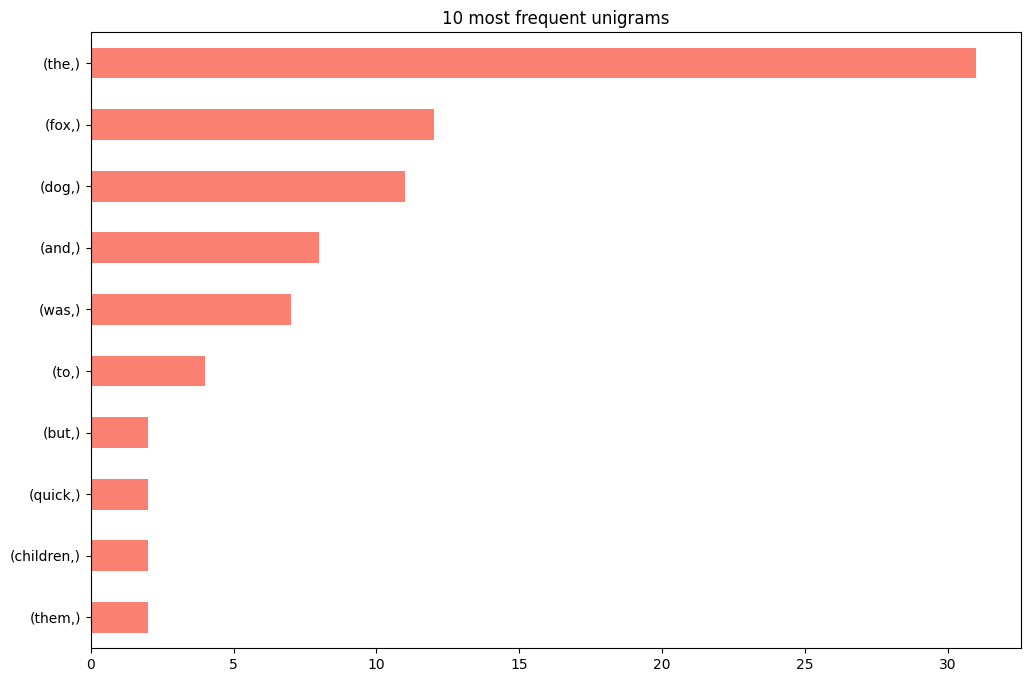

In [31]:
unigrams[:10].sort_values().plot.barh(color = 'salmon', figsize = (12, 8))
plt.title('10 most frequent unigrams')

In [32]:
print(pd.Series(nltk.ngrams(tokens, 2)).value_counts())

(the, fox)         11
(the, dog)         10
(fox, was)          4
(and, the)          3
(garden, and)       2
                   ..
(dog, returned)     1
(then, the)         1
(dog, then)         1
(escaped, the)      1
(the, trees)        1
Name: count, Length: 102, dtype: int64


In [33]:
print(pd.Series(nltk.ngrams(tokens, 3)).value_counts())

(the, fox, was)        4
(the, fox, watched)    2
(and, the, dog)        2
(the, dog, was)        2
(the, garden, and)     2
                      ..
(then, the, dog)       1
(dog, then, the)       1
(the, dog, then)       1
(escaped, the, dog)    1
(in, the, trees)       1
Name: count, Length: 128, dtype: int64
